In [3]:
print("h")

h


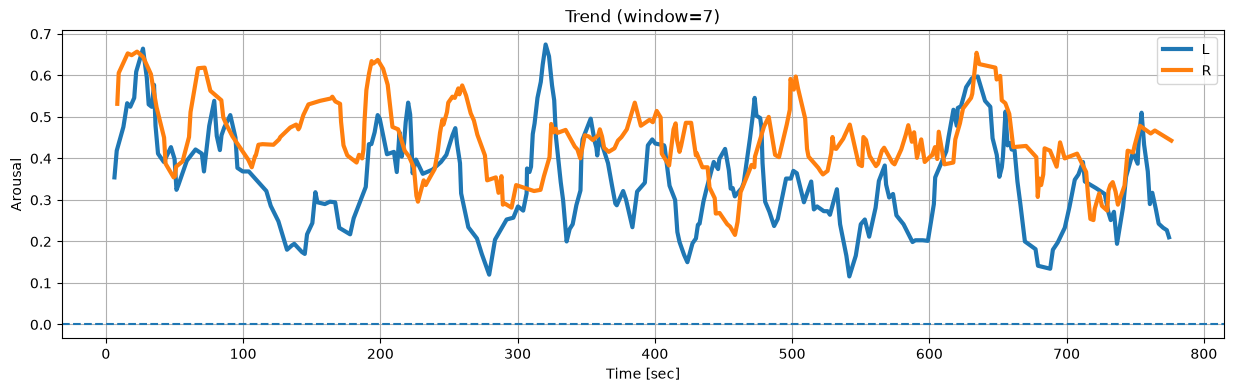

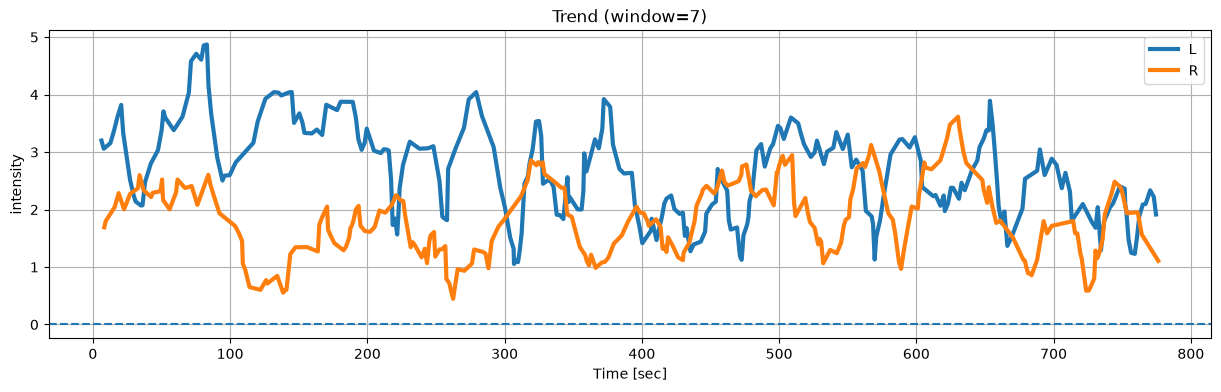

In [5]:
# 成功しました！
import pandas as pd
import matplotlib.pyplot as plt

L_csv = "/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/vad_delta_L.csv"
R_csv = "/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/vad_delta_R.csv"
seg_csv = "/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/Segments/D03F0001/D03F0001_segments.csv"  # 時間情報あり

df_L = pd.read_csv(L_csv)
df_R = pd.read_csv(R_csv)
segments = pd.read_csv(seg_csv)

# ==========================
# filename形式を合わせる
# ==========================

# vad側:
# 0001_L.wav

# segments側:
# 1_L.wav

# 先頭0を除去
df_L["wavfile"] = df_L["filename"].str.lstrip("0")
df_R["wavfile"] = df_R["filename"].str.lstrip("0")


# ==========================
# 時刻情報を追加
# ==========================

df_L = df_L.merge(
    segments[["wavfile","start","end"]],
    on="wavfile",
    how="left"
)


df_R = df_R.merge(
    segments[["wavfile","start","end"]],
    on="wavfile",
    how="left"
)

# ==========================
# 可視化（窓サイズ7 移動平均）
# ==========================

window = 7

# 移動平均を追加
df_L["arousal_ma"] = (
    df_L["arousal"]
    .rolling(window=window, center=True)    # center=True;未来の発話を使う
    .mean()
)

df_R["arousal_ma"] = (
    df_R["arousal"]
    .rolling(window=window, center=True)
    .mean()
)

# 移動平均を追加
df_L["intensity_ma"] = (
    df_L["intensity_pred_kushinada"]
    .rolling(window=window, center=True)    # center=True;未来の発話を使う
    .mean()
)

df_R["intensity_ma"] = (
    df_R["intensity_pred_kushinada"]
    .rolling(window=window, center=True)
    .mean()
)

# arousalのグラフ
plt.figure(figsize=(15,4))

# 移動平均
plt.plot(
    df_L["start"],
    df_L["arousal_ma"],
    label="L",
    linewidth=3
)


plt.plot(
    df_R["start"],
    df_R["arousal_ma"],
    label="R",
    linewidth=3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time [sec]")
plt.ylabel("Arousal")

plt.title(
    "Trend (window=7)"
)

plt.legend()
plt.grid()
plt.show()

# intensityのグラフ
plt.figure(figsize=(15,4))

plt.plot(
    df_L["start"],
    df_L["intensity_ma"],
    label="L",
    linewidth=3
)


plt.plot(
    df_R["start"],
    df_R["intensity_ma"],
    label="R",
    linewidth=3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time [sec]")
plt.ylabel("intensity")

plt.title(
    "Trend (window=7)"
)

plt.legend()
plt.grid()
plt.show()